In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

In [38]:
binary_summary = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/stats/binary_summary.csv")
binary_metrics = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/stats/binary_metrics.csv")
binary_cm = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/stats/binary_confusion_matrix.csv", index_col=0)

strict_summary = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/stats/strict_multiclass_summary.csv")
strict_metrics = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/stats/strict_multiclass_metrics.csv")
strict_cm = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/stats/strict_multiclass_confusion_matrix.csv", index_col=0)

ovr_metrics = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/stats/one_vs_rest_metrics.csv")
eval_input = pd.read_csv("../results/range_1_4001_timeout_180/range_1_4001/eval_input.csv")

In [39]:
print(binary_summary)
print()
print(strict_summary)
print()
display(binary_metrics)
display(strict_metrics)
display(ovr_metrics)

   accuracy  macro_f1  n_rows
0  0.537864  0.528047    5533

   accuracy  macro_f1_excluding_multi  n_rows
0   0.28068                   0.15401    5533



,label,precision,recall,f1,support
0,SAFE,0.493430,0.430775,0.459979,2528
1,UNSAFE,0.567348,0.627953,0.596114,3005


,label,precision,recall,f1,support
0,SAFE,0.492564,0.432358,0.460501,2528
1,BN,0.060606,0.068376,0.064257,117
2,DE,0.452830,0.363636,0.403361,66
3,EF,0.000000,0.000000,0.000000,67
4,OF,0.069632,0.092072,0.079295,391
5,RE,0.267089,0.376365,0.312448,1007
6,SE,0.388889,0.029289,0.054475,239
7,TP,0.000000,0.000000,0.000000,128
8,UC,0.193548,0.006061,0.011753,990
9,MULTI,0.000000,0.000000,0.000000,0


,label,positive_class_precision,positive_class_recall,positive_class_f1,accuracy,support_positive,support_negative
0,BN,0.152047,0.444444,0.226580,0.865784,117,2528
1,DE,0.820513,0.484848,0.609524,0.984194,66,2528
2,EF,0.108108,0.119403,0.113475,0.951830,67,2528
3,SE,0.228070,0.054393,0.087838,0.902421,239,2528
4,OF,0.077475,0.138107,0.099265,0.664269,391,2528
5,RE,0.392603,0.548163,0.457522,0.629703,1007,2528
6,TP,0.000000,0.000000,0.000000,0.951807,128,2528
7,UC,0.432602,0.139394,0.210848,0.706367,990,2528


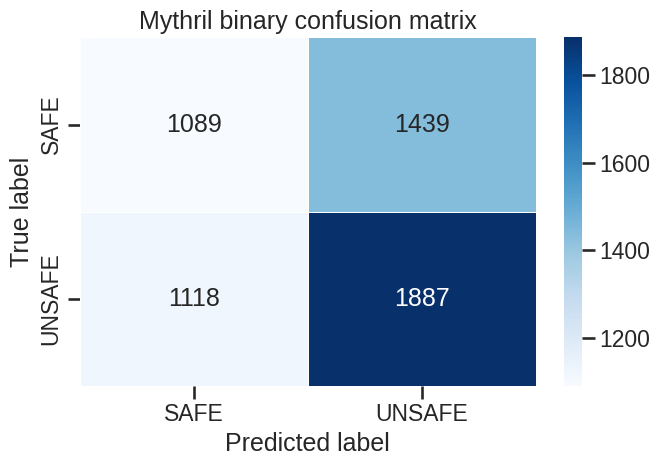

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    binary_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Mythril binary confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig("../Graphs/mythril/mythril_binary_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

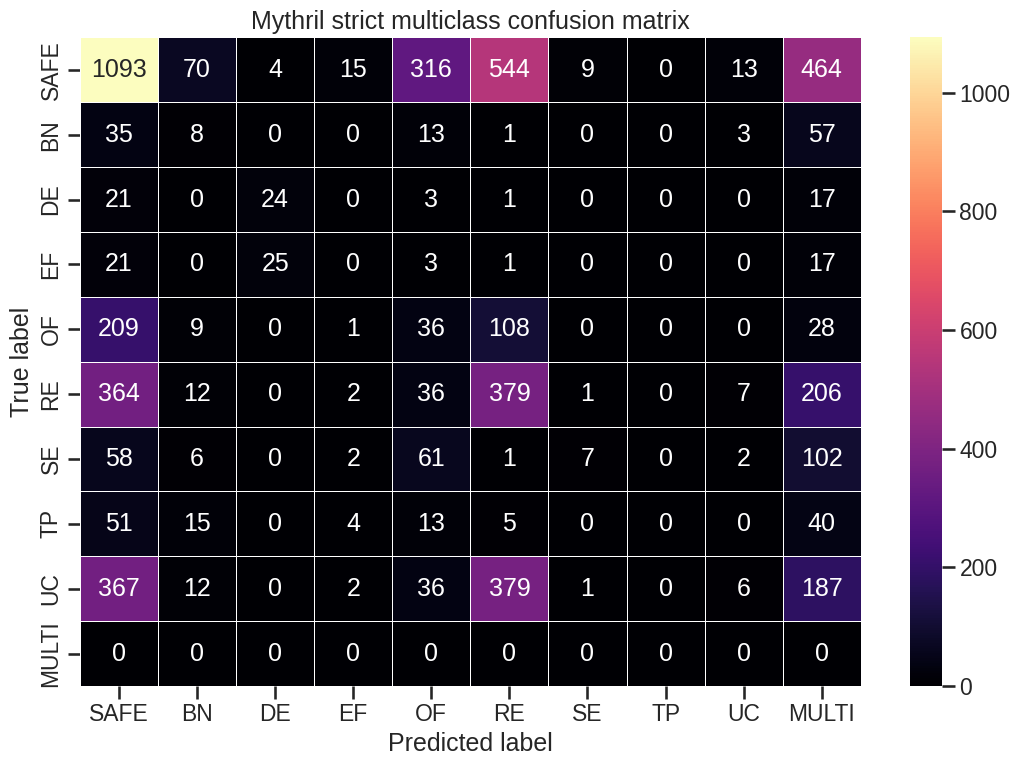

In [41]:
fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    strict_cm,
    annot=True,
    fmt="d",
    cmap="magma",
    cbar=True,
    linewidths=0.4,
    linecolor="white",
    ax=ax
)

ax.set_title("Mythril strict multiclass confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig("../Graphs/mythril/mythril_strict_multiclass_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

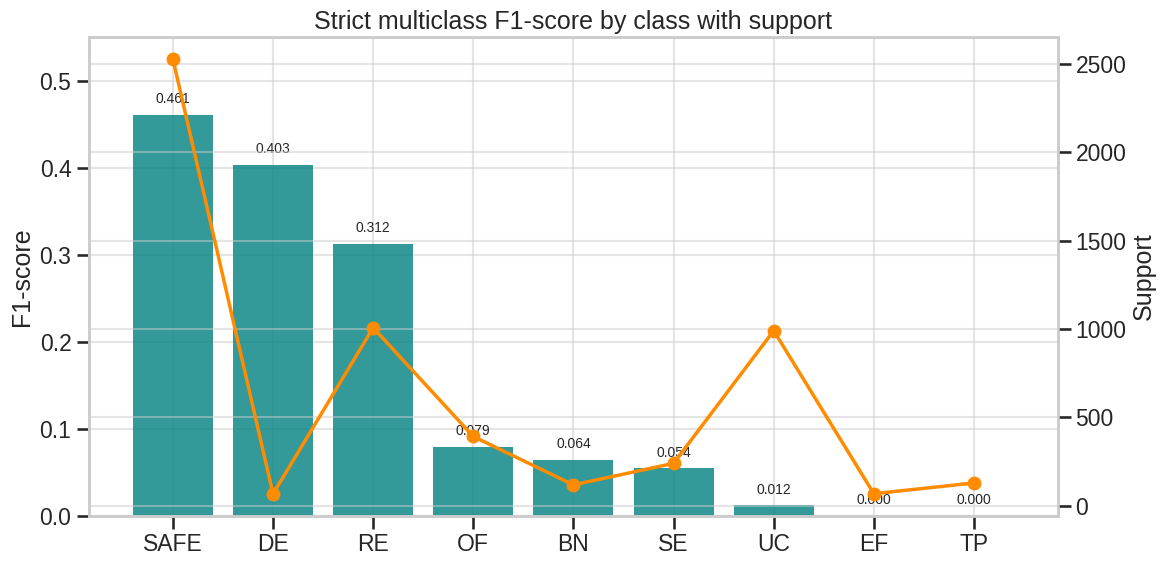

In [42]:
strict_plot = strict_metrics[strict_metrics["label"] != "MULTI"].copy()
strict_plot = strict_plot.sort_values("f1", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(strict_plot["label"], strict_plot["f1"], color="teal", alpha=0.8, label="F1-score")
ax1.set_ylabel("F1-score")
ax1.set_ylim(0, 0.55)
ax1.set_title("Strict multiclass F1-score by class with support")

ax2 = ax1.twinx()
ax2.plot(strict_plot["label"], strict_plot["support"], color="darkorange", marker="o", linewidth=2.5, label="Support")
ax2.set_ylabel("Support")

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("../Graphs/mythril/mythril_strict_multiclass_f1_support.png", dpi=300, bbox_inches="tight")
plt.show()

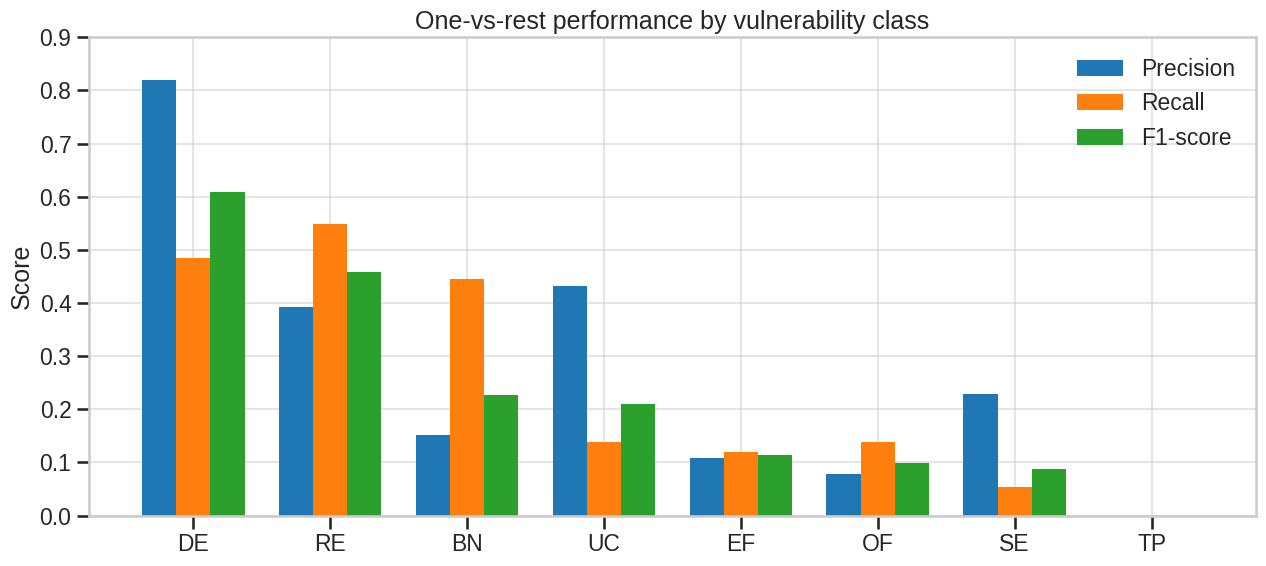

In [43]:
ovr_plot = ovr_metrics.copy()
ovr_plot = ovr_plot.sort_values("positive_class_f1", ascending=False)

x = np.arange(len(ovr_plot))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - w, ovr_plot["positive_class_precision"], width=w, label="Precision", color="#1f77b4")
ax.bar(x,     ovr_plot["positive_class_recall"],    width=w, label="Recall",    color="#ff7f0e")
ax.bar(x + w, ovr_plot["positive_class_f1"],        width=w, label="F1-score",  color="#2ca02c")

ax.set_xticks(x)
ax.set_xticklabels(ovr_plot["label"])
ax.set_ylim(0, 0.9)
ax.set_ylabel("Score")
ax.set_title("One-vs-rest performance by vulnerability class")
ax.legend()

plt.tight_layout()
plt.savefig("../Graphs/mythril/mythril_one_vs_rest_performance.png", dpi=300, bbox_inches="tight")
plt.show()

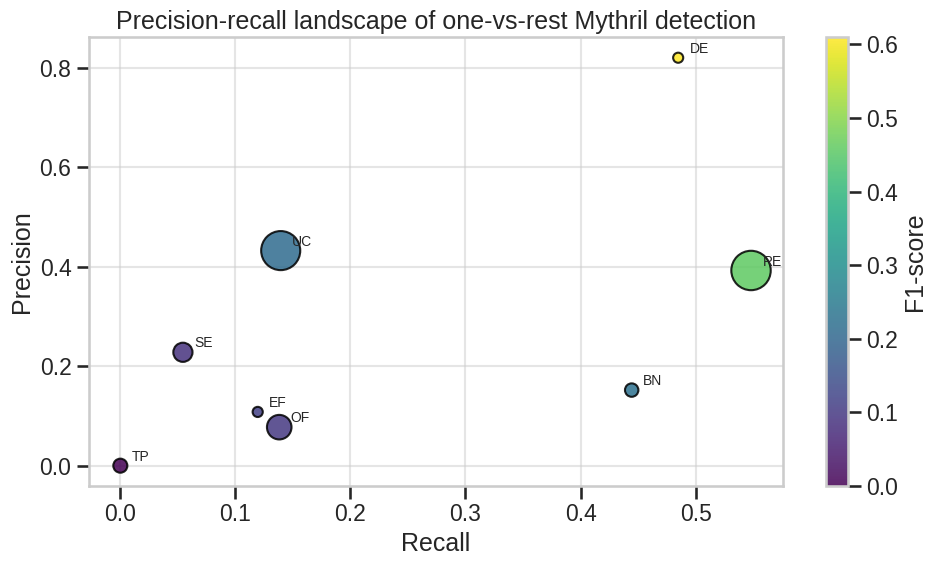

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    ovr_metrics["positive_class_recall"],
    ovr_metrics["positive_class_precision"],
    s=ovr_metrics["support_positive"] * 0.8,
    c=ovr_metrics["positive_class_f1"],
    cmap="viridis",
    alpha=0.85,
    edgecolor="black"
)

for _, row in ovr_metrics.iterrows():
    ax.text(
        row["positive_class_recall"] + 0.01,
        row["positive_class_precision"] + 0.01,
        row["label"],
        fontsize=10
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall landscape of one-vs-rest Mythril detection")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("F1-score")

plt.tight_layout()
plt.savefig("../Graphs/mythril/mythril_precision_recall_landscape.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_77644/1170662513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_counts, x="status", y="count", palette="Set2", ax=ax)


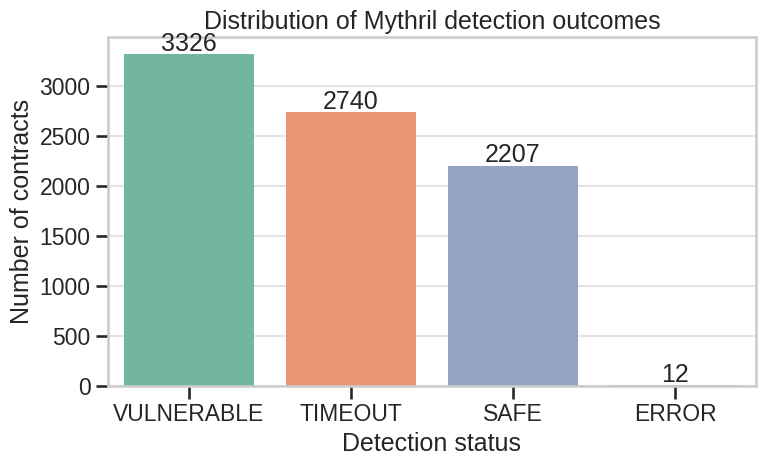

In [45]:
status_counts = eval_input["detection_status"].value_counts().reset_index()
status_counts.columns = ["status", "count"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=status_counts, x="status", y="count", palette="Set2", ax=ax)

ax.set_title("Distribution of Mythril detection outcomes")
ax.set_xlabel("Detection status")
ax.set_ylabel("Number of contracts")

for i, row in status_counts.iterrows():
    ax.text(i, row["count"] + max(status_counts["count"]) * 0.01, str(row["count"]), ha="center")

plt.tight_layout()
plt.savefig("../Graphs/mythril/mythril_detection_outcomes.png", dpi=300, bbox_inches="tight")
plt.show()